In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [2]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
datos_penguins = datos_penguins.dropna()

Que preguntas me hago respecto a esto?
- Los pinguinos estan en todas las islas? O las especies residen en alguna islas en particular?
- Hay diferencias en las cualidades fisicas entre los pinguinos femenino y masculino de las especies?
- Los pinguinos, se mueven entre estas islas? Es decir, las mediciones, si hubieran sido tomadas al dia siguiente, puede un pinguino haber estado en otra de estas islas? O son inaccesibles entre si?

In [3]:
categoricas = datos_penguins.select_dtypes(include=['object', 'category'])
categoricas.value_counts()

species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Male      22
                      Female    22
Name: count, dtype: int64

Las razas Gento y Chinstrap aparecen en una sola isla. La raza Adelie es la unica que aparece en la isla Torgensen, por lo que es un buen atributo para identificar varios ejemplares.

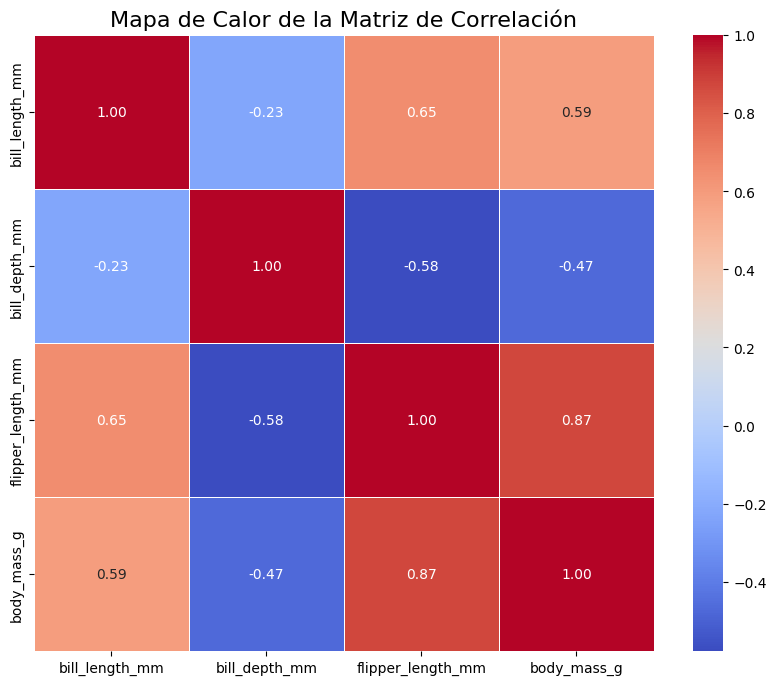

In [4]:
# Calcular la matriz de correlación
matriz_corr = datos_penguins.select_dtypes(include=['float64', 'int64']).corr()

# Visualización con Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)
plt.show()

Esta matriz se ve bastante rara: sin previo analisis, uno diria que para "los pinguinos del archipielago palmer", las variables relacionadas a las dimensiones del pico, estan poco correlacionadas, en comparacion a el peso y el tamaño de la aleta cuando uno lo que tenderia a pensar es que "Pinguino mas grande -> pico mas grande", por lo que espero esto sea producto de alguna correlacion espuria.

Analizemos el scatter.

Vamos a graficar las dos relaciones mas fuertes que detectamos en el inciso anterior:
- La negativa mas alta (-0,58: profundidad del pico vs aleta)
- La positiva mas alta (0,87): Aleta vs masa corporal

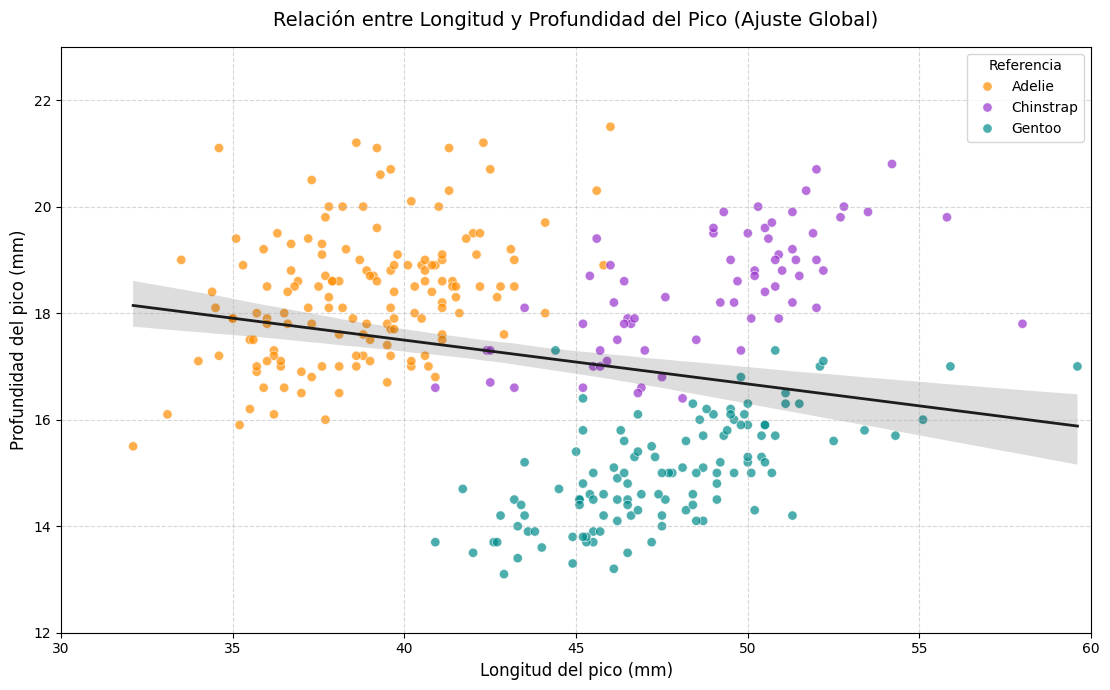

Ecuación de regresión global y Coeficiente de Determinación (R²):
  y = -0.0823x + (20.7866)
  R² = 0.0523 (r = -0.2286, p-valor = 2.528e-05)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# paleta
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

#Grafico
fig, ax = plt.subplots(figsize=(11.2, 7))

# Puntos diferenciados por especie
sns.scatterplot(
    data=datos_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=paleta_penguins,
    alpha=0.7,
    s=45,
    ax=ax,
)

# Ajuste lineal global ajustado al rango real de los datos (truncate=True)
sns.regplot(
    data=datos_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    scatter=False,
    color="#1C1C1C",
    truncate=True,
    ax=ax,
    line_kws={'linewidth': 2, 'linestyle': '-', 'label': 'Ajuste global'},
)

# Límites ajustados al dominio de las variables (evita distorsión de escala)
ax.set_xlim(30, 60)
ax.set_ylim(12, 23)

# Título y etiquetas
ax.set_title(
    "Relación entre Longitud y Profundidad del Pico (Ajuste Global)",
    fontsize=14,
    pad=15,
)
ax.set_xlabel("Longitud del pico (mm)", fontsize=12)
ax.set_ylabel("Profundidad del pico (mm)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Referencia")

plt.tight_layout()
plt.show()

# calculo de la regresión global
df_filtrado = datos_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

x = df_filtrado['bill_length_mm']
y = df_filtrado['bill_depth_mm']

regresion = linregress(x, y)
m = regresion.slope
b = regresion.intercept
r2 = regresion.rvalue**2
p_val = regresion.pvalue

print("Ecuación de regresión global y Coeficiente de Determinación (R²):")
print(f"  y = {m:.4f}x + ({b:.4f})")
print(f"  R² = {r2:.4f} (r = {regresion.rvalue:.4f}, p-valor = {p_val:.3e})")

Ahi esta el -0.23! los puntos caen en la parte superior izquierda para una especie, e inferior derecha para otra, por lo que la correlacion tiende a ser negativa.

Veamos los arreglos lineales para las especies por separado

Correlaciones:
                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.228626
bill_depth_mm        -0.228626       1.000000
--------------------------------------------------
Correlación Global:
r = -0.2286 | p-valor = 2.5283e-05
--------------------------------------------------
Correlación por Especie:
Adelie     -> r = 0.3858 | p-valor = 1.5149e-06
Chinstrap  -> r = 0.6535 | p-valor = 1.5255e-09
Gentoo     -> r = 0.6540 | p-valor = 7.3366e-16


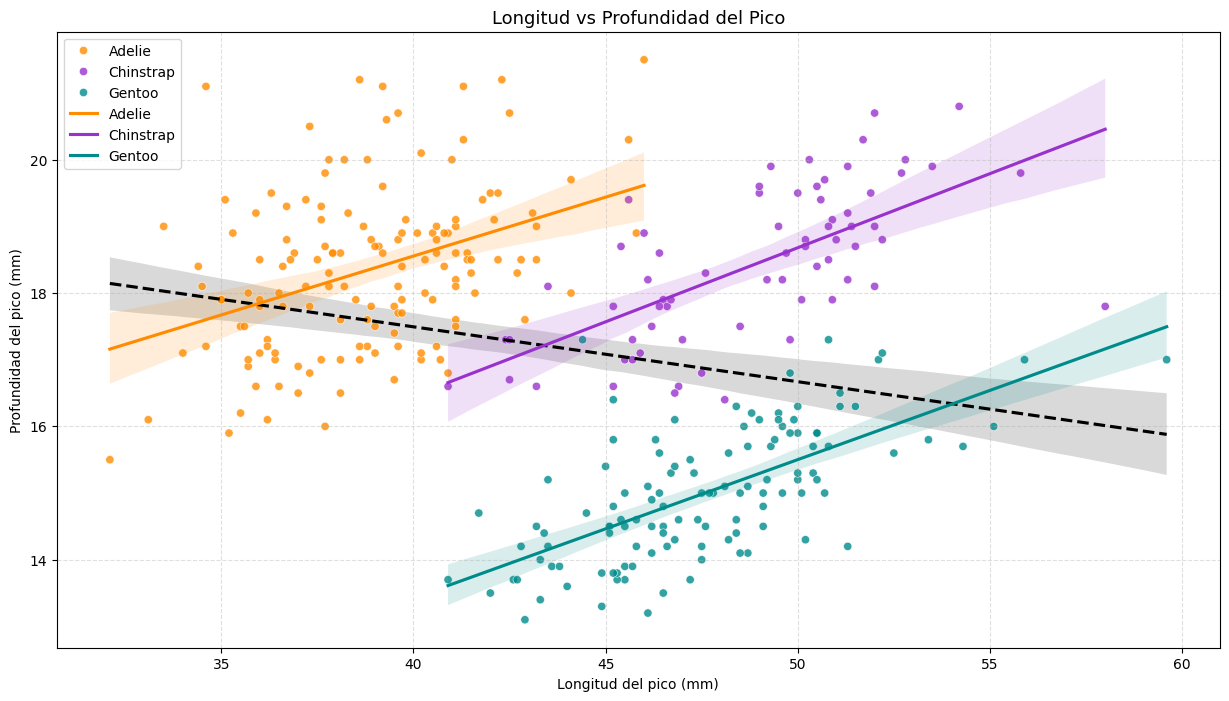

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = datos_penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("Correlaciones:")
print(df[['bill_length_mm', 'bill_depth_mm']].corr())
print("-" * 50)

# coeficiente de pearson y p-valor para todos
r_global, p_global = pearsonr(df['bill_length_mm'], df['bill_depth_mm'])
print(f"Correlación Global:")
print(f"r = {r_global:.4f} | p-valor = {p_global:.4e}")
print("-" * 50)

# pr especie
print("Correlación por Especie:")
for especie, grupo in df.groupby('species'):
    r_esp, p_esp = pearsonr(grupo['bill_length_mm'], grupo['bill_depth_mm'])
    print(f"{especie:10s} -> r = {r_esp:.4f} | p-valor = {p_esp:.4e}")
fig, ax = plt.subplots(figsize=(15, 8))

# Regresión global (línea punteada negra), usamos scatter=False para q no dibuje los puntos, solo la linea
sns.regplot(
    data=df, x="bill_length_mm", y="bill_depth_mm",
    scatter=False, ax=ax, color='black',
    line_kws={'linestyle': '--', 'label': f'Global (r={r_global:.2f})'}
)

# Regresiones por especie
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", palette=paleta_penguins, ax=ax, alpha=0.8)
for especie, color in paleta_penguins.items():
    sub = df[df['species'] == especie]
    sns.regplot(data=sub, x="bill_length_mm", y="bill_depth_mm", scatter=False, ax=ax, color=color, label=especie)

ax.set_title("Longitud vs Profundidad del Pico", fontsize=13)
ax.set_xlabel("Longitud del pico (mm)")
ax.set_ylabel("Profundidad del pico (mm)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

Bastante mas coherente! Para las 3, el hecho de que aumente una caracteristica, hace que aumente la otra.

Ademas, vemos que existen significancias estadisticas para los tests hechos

Veamos las relaciones mas fuertes que detectamos en el heatmap global

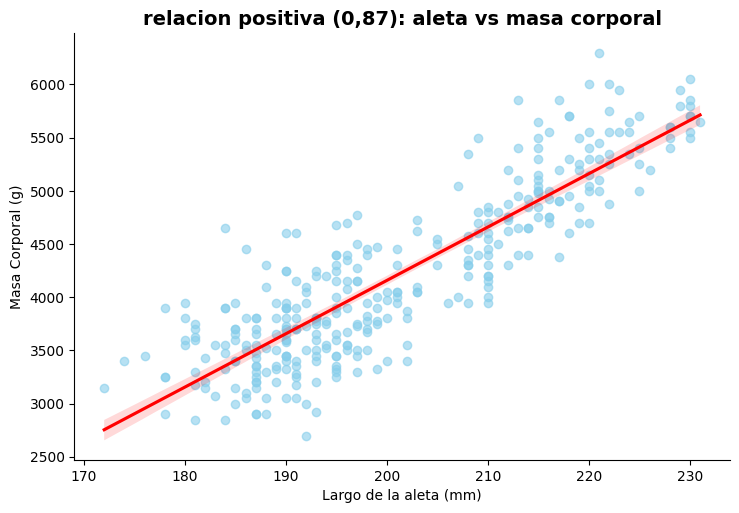

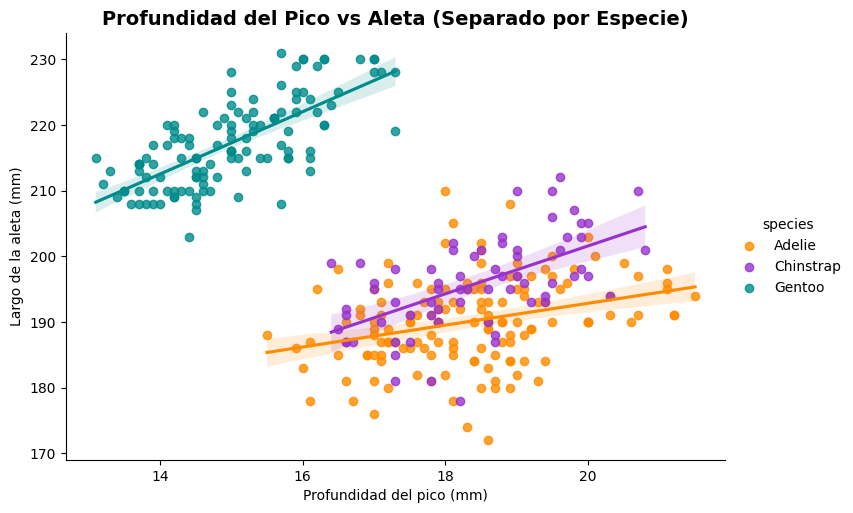

In [16]:
#relacion positiva

#lmplot calcula y dibuja la linea de tendencia y ademas llama a scatterplot
grafico_positivo=sns.lmplot(data=datos_penguins,x='flipper_length_mm',
                    y='body_mass_g',
                    scatter_kws={'alpha':0.6,'color':'skyblue'}, #puntos
                    line_kws={'color':'red'}, #linea de tendencia
                    aspect=1.5 #ensancha un poco el grafico
)

plt.title("relacion positiva (0,87): aleta vs masa corporal",fontsize=14,fontweight='bold')
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Masa Corporal (g)")
plt.show()

#relacion negativa
#agregamos hue='species' (todo de la IA esto), para dibujar 3 nubes de puntos
#y 3 lineas de tendencia
grafico_negativo = sns.lmplot(
    data=datos_penguins, 
    x='bill_depth_mm', 
    y='flipper_length_mm',
    hue='species',      # dividimos por especie
    palette=paleta_penguins,
    aspect=1.5
)
plt.title("Profundidad del Pico vs Aleta (Separado por Especie)", fontsize=14, fontweight='bold')
plt.xlabel("Profundidad del pico (mm)")
plt.ylabel("Largo de la aleta (mm)")
plt.show()

In [19]:
# coeficiente de pearson y p-valor para todos
r_global, p_global = pearsonr(df['flipper_length_mm'], df['bill_depth_mm'])
print(f"Correlación Global:")
print(f"r = {r_global:.4f} | p-valor = {p_global:.4e}")
print("-" * 50)



Correlación Global:
r = -0.5778 | p-valor = 4.7782e-31
--------------------------------------------------


Como conclusion inicial podemos decir que los números 'globales' pueden ser engañosos si no conocemos o intuimos la naturaleza o biologia de nuestros datos. Me hacia un poco de ruido pensar que si un pinguino era mas grande tenia el pico mas chato y el separar por especie permitio determinar que se debia a que simplemente el resultado global fue engañoso por que metimos a todas las especies en la misma bolsa.

- Aleta vs masa corporal: la nube de puntos y la linea de tendencia apunta clarmente hacia arriba y a la derecha, la conclusion es directa y aplica para todos los pinguinos por igual: A mayor longitud de aleta, mayor es la masa corporal del animal. Esta regla es puramente biologica y tiene todo el sentido.
- Profundidad del pico vs aleta: Este fue nuestro descubriento hasta ahora, el hatmap ns advirtio que la relacion entre el grosor del pico y el largo de la aleta era fuertemente negativa,por lo que se podia pensar que aleta mas larga =pico mas fino. Gracias al segundo grafico verificamos que mi sospecha era cierta. Notamos que dentro de cada especie individual, la linea de tendencia apunta hacia ARRIBA. Gracias a natgeo y discovery podemos decir que biologicamente si el pinguino es mas grande, su pico tambien es mas grueso (la relacion interna por especie es positiva.)


Veamos ahora las distribuciones de las variables

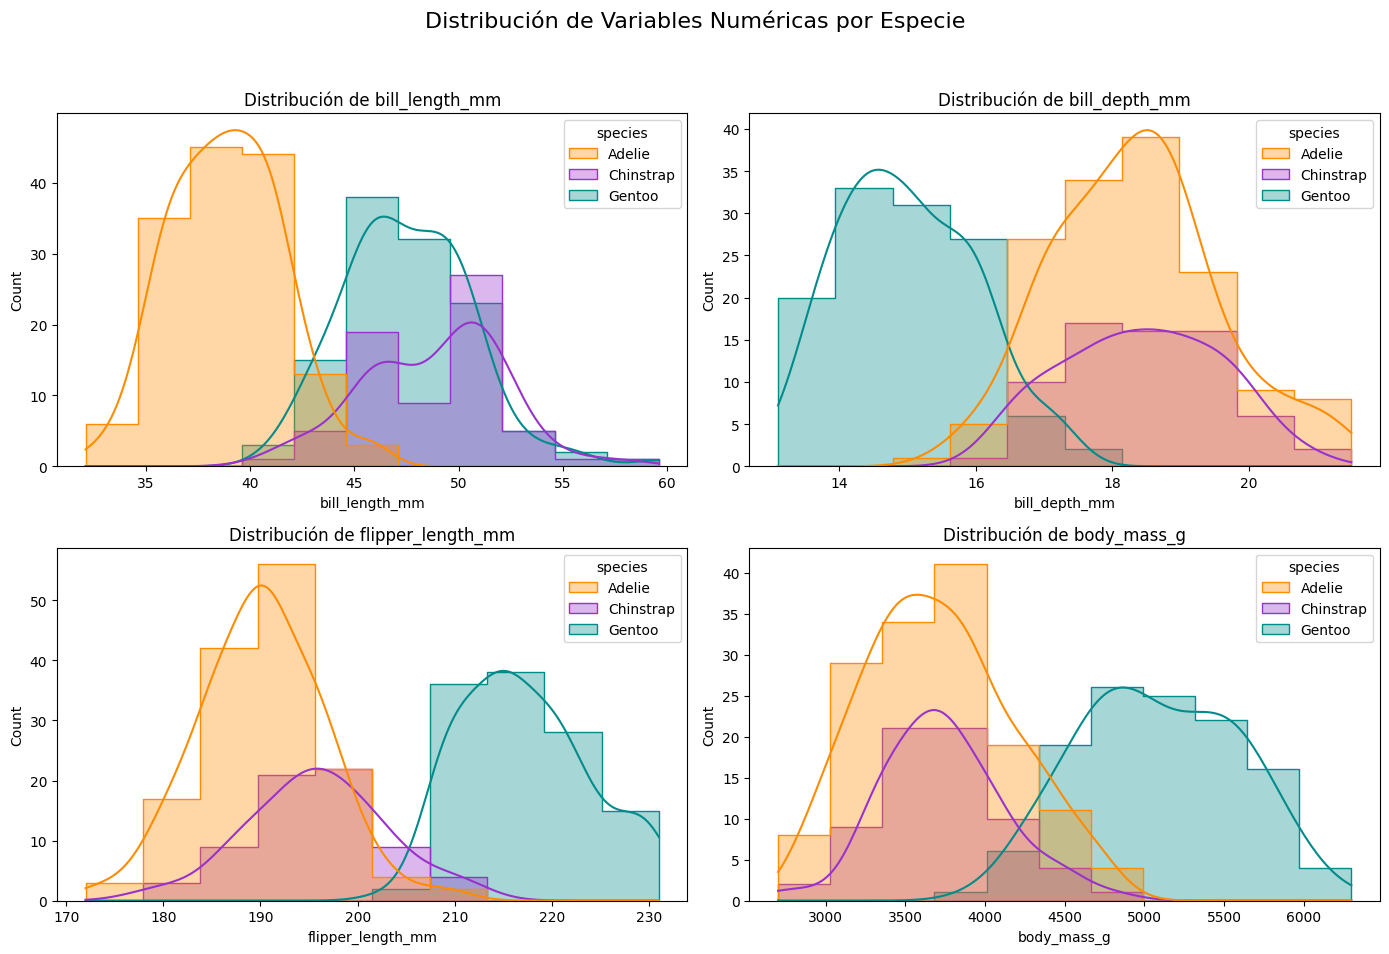

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#extraemos los nombres pa dsp graficar
columnas_numericas = datos_penguins.select_dtypes(include=['float64', 'int64']).columns

# Paleta específica
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    ax = axes[i // 2, i % 2]
    
    sns.histplot(
        data=datos_penguins,
        x=col,
        hue='species',
        kde=True,
        ax=ax,
        palette=paleta_penguins,
        alpha=0.35,
        element="step",       # Delinea los bordes evitando que las barras se tapen
        common_norm=False     # Normaliza la densidad de cada especie de forma independiente
    )
    ax.set_title(f'Distribución de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Aca podemos ver mejor en comparacion a los graficos univariados! Vemos que la especie Gentoo es la que estaba generando las colas pesadas, debido a que tiene un numero similar de muestras que la Adelie, y son bastantes separables por el tamaño de los pinguinos en general! (Mas peso, mayor tamaño de aleta, y largo de pico), peeeero, tiene una peculiaridad: el alto de su pico es mas chico, por lo que me imagino una especie de pinguino con un pico mas "alapisado". 

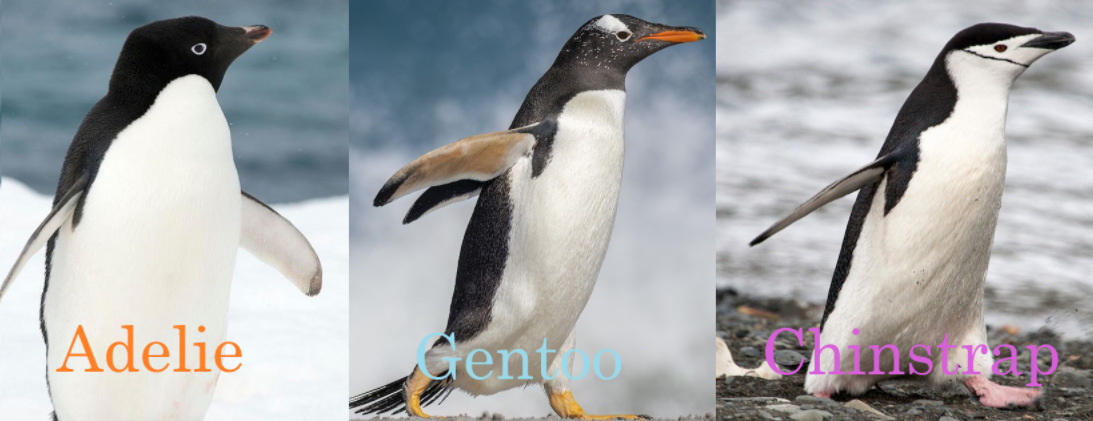

Podemos ademas, ver los boxplots, cosa de que quede mas claro a la vista

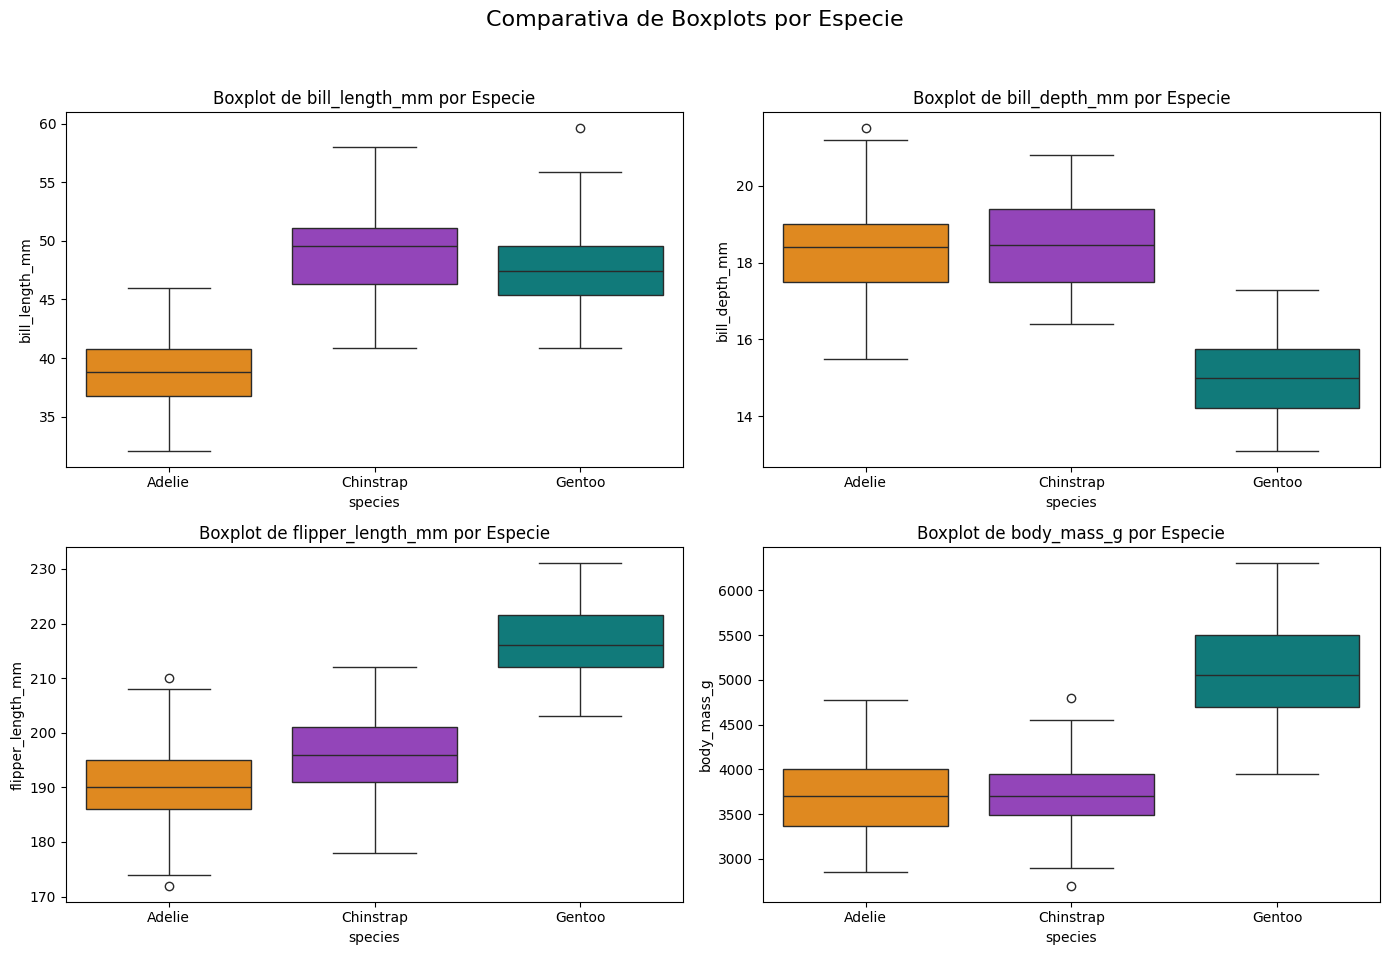

In [10]:
# Boxplots segmentados por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Boxplots por Especie', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=datos_penguins, x='species', y=col, hue='species', ax=axes[i//2, i%2], palette=paleta_penguins, legend=False)
    axes[i//2, i%2].set_title(f'Boxplot de {col} por Especie')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Veamos ahora las tablas de contingencia, y el test de chi-cuadrado!

hacemos un chi-cuadrao, nivel de signifcancia 0,05

especie vs isla_
- H0:la especie es independiente de la isla
- H1: la especie es dependiente de la isla

sexo vs especie
- H0:el sexo es independiente de la especie
- H1: el sexo es dependiente de la especie

sexo vs isla
- H0: el sexo del pinguino es independiente de su isla
- H1: existe una dependecncia entre el sexo y la isla


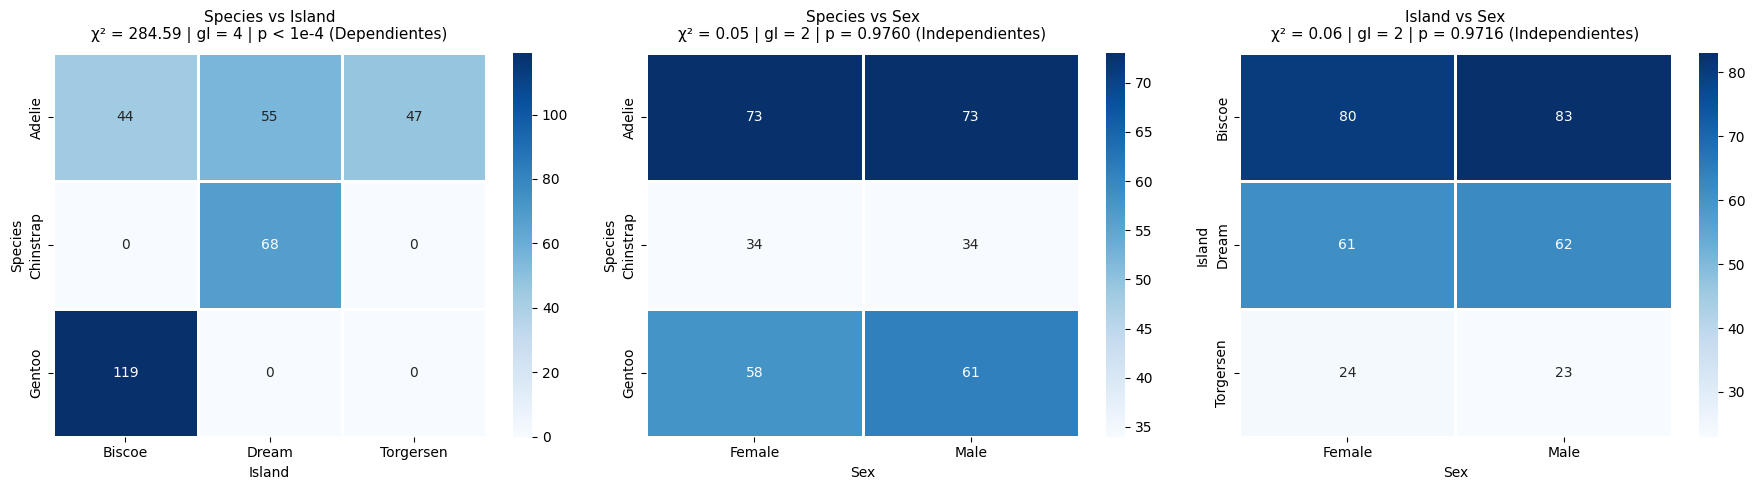

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

#filtrado 
df_cat = datos_penguins.dropna(subset=['species', 'island', 'sex'])

pares = [
    ('species', 'island'),
    ('species', 'sex'),
    ('island', 'sex')
]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (var1, var2) in zip(axes, pares):
    # Tabla de contingencia
    tabla_obs = pd.crosstab(df_cat[var1], df_cat[var2])
    
    # Test de Independencia Chi-cuadrado
    chi2, p_val, dof, expected = chi2_contingency(tabla_obs)
    
    # Heatmap de frecuencias observadas
    sns.heatmap(
        tabla_obs, #los datillos
        annot=True, #pa q escriba el nro adentro del cuadradito creo
        fmt='d', #numeros enteros
        cmap='Blues',
        linewidths=0.8,
        linecolor='white',
        cbar=True,
        ax=ax #le indica donde dibujar todo
    )
    
    # Formateo del p-valor para el título
    p_text = f"p < 1e-4" if p_val < 0.0001 else f"p = {p_val:.4f}"
    decision = "Dependientes" if p_val < 0.05 else "Independientes"
    
    ax.set_title(
        f"{var1.capitalize()} vs {var2.capitalize()}\n"
        f"χ² = {chi2:.2f} | gl = {dof} | {p_text} ({decision})",
        fontsize=11,
        pad=10
    )
    ax.set_xlabel(var2.capitalize(), fontsize=10)
    ax.set_ylabel(var1.capitalize(), fontsize=10)

plt.tight_layout()
plt.show()

El X^2 indica que tan diferentes son los datos reales comparados con lo que uno esperaria si las variables fueran independientes
- Si es 0 significa que los datos son identicos
- Mientras mas grande sea este numero, mas raras son las tablas lo que indica que las variables estan conectadas

El gl indica algo relacionado al tamaño de la tabla, no interesa tanto en realidad

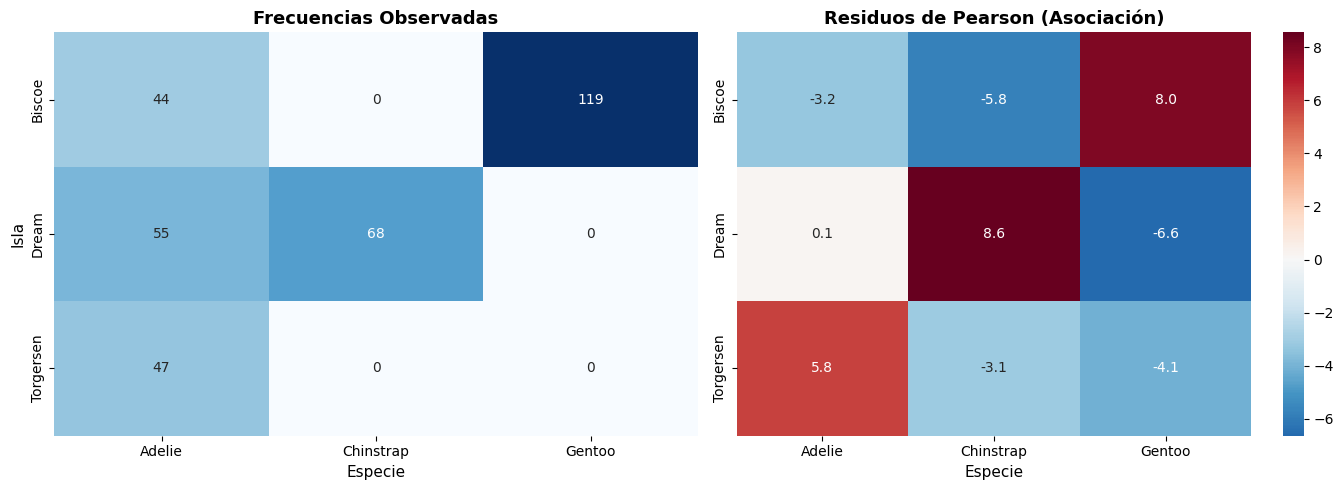

In [ ]:
from scipy.stats import chi2_contingency

#volvemos a crear la tabla
tabla_isla_especie=pd.crosstab(datos_penguins['island'],datos_penguins['species'])

#calculamos los valores esperados usando chi-cuadrado (tal cual esta en la teoria)
chi2,p,gl,esperado=chi2_contingency(tabla_isla_especie)

#calculamos los "residuos de pearson" que tiene la siguiente formula
#(observado - esperado)/raiz cuadrada de esperado
residuos=(tabla_isla_especie - esperado)/np.sqrt(esperado)

#visualizamos
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#heatmpa 1, frecuencias observadas
sns.heatmap(tabla_isla_especie, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False)
ax[0].set_title("Frecuencias Observadas", fontsize=13, fontweight='bold')
ax[0].set_ylabel("Isla", fontsize=11)
ax[0].set_xlabel("Especie", fontsize=11)

#heatmap 2, residuos de pearson (es el equivalente a la correlacion)
sns.heatmap(residuos, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Residuos de Pearson (Asociación)", fontsize=13, fontweight='bold')
ax[1].set_ylabel("") # Quitamos el título de y para no repetir
ax[1].set_xlabel("Especie", fontsize=11)
plt.tight_layout()
plt.show()



Podemos notar que a pesar de que la especie Adelie no tiene una isla preferida, se distribuye casi de manera identica en las 3 islas.

En cuanto a las proporciones de cada isla , vemos que la Dream es la mas equilibrada. Por su parte, en Biscoe se ve que la especie dominante es la Gentoo (con el total de su poblacion) , mientras que la especie Adelie es la minoria.

Ya se puede notar que hay dependencia entre isla y especie, aunque sea en el conjunto de datos que estamos estudiando, y esto significa que una varibale da informacion sobre la otra. 
Por ejemplo, si sabemos que un pinguino es Gentoo, tenemos 100% de certeza de que vive en Biscoe o que si nos encontramos en Torgensen, tenemos 100% de certeza de que el pinguino es Adelie.

La diagonal roja que se observa nos dice que cada especie tiene un territorio fuertemente asociado a ella.
- Ademas de las asociaciones fuertes de chinstrap y la isla dream o Gentoo con la isla Biscoe , como Adelie es la unica especie que habita en Torgensen, tambien hay una asociacion alta.

Los cuadrados azul oscuro indican que las especies evitan o no pueden sobrevivir en esas islas. (**esto es una suposicion, tipo para darle alguna explicacion**) 
- Una observacion interesante que noto es el de Adelie en Biscoe. El color azul (-3,2) indica que son menos de lo esperado, esto entiendo que pasa debido a que Adelie es la especie mas estudiada en la estación, y deberian haber muchos mas.

Luego otro resultado interesante es el de Adelie en la isla Dream, significa que los 55 pinguinos son la cantidad casi exacta que la probabilidad esperaba. Quiere decir que Adelie convive tranqui con Chinstrap, son amiguitos.

Podemos concluir entonces que la distribucion de especies no es aleatoria y que esta determinada por la geografia de las islas.


Un dato bastante peculiar es que la isla Torgensen tiene menos muestras, pero pasa lo siguiente

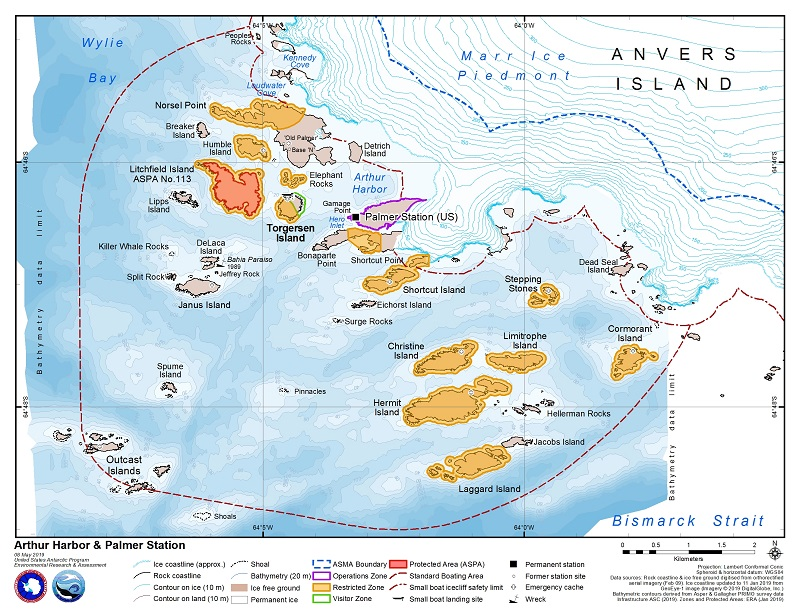

Como se ve en la imagen, la isla Torgensen es la mas cercana a la estacion desde donde se tomaron las muestras, pero la mitad de esta se encuentra dentro del tratado antartico (https://www.ats.aq/devAS/Ats/Guideline/5fb4eff9-a4cb-4366-90d0-e891afdc4963?lang=s), y es el lugar donde se reproducen los pinguinos de Adelie,

Ademas, se estudian esta isla el comportamiento de la especie Adelie, tanto en contacto humano, como sin estar en contacto, estando restringido el acceso a la mitad de la isla

Por otro lado, las muestras entre sexo y especie, y sexo e isla, no tienen significancia estadistica, y se ve bastante claro esto, ya que las columnas no tiene variacion entre si

## reporte del analisis bivariado
- la asociacion mas confiable es la relacion lineal positiva entre el largo de la aleta y la masa corporal, es una regla biologica constante en toda la poblacion.
- la variable predictora principal es el largo de la aleta ('flipper_length_mm'). Creo que es la que mas potencial tiene para estimar el peso de un individuo sin tener en cuenta su especie.
- la variable 'species' es la predictora que relaciona el tamaño y grosor del pico, cualquier modelo predictivo va a funcionar mal si no tiene estratifica los datos utilizando la especie como condicionante.
- Si el objetivo futuro fuera entrenar un modelo de clasificación para adivinar la especie de un pingüino desconocido, vimos que la profundidad del pico y el largo del mismo diferenciaba muy bien a los grupos, basicamente es un clasificador natural